In [11]:
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import BaseMessage, SystemMessage,HumanMessage
from typing_extensions import Annotated, TypedDict
from utils import groq_llm, groq_llm_with_tools,gemini_llm1_with_tools
from database import checkpointer
from prompts import SYSTEM_PROMPT
from tools import tools


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


23 documents loaded
Document split into 33 chunks


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [12]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [13]:
def chat_node(state: ChatState):
    messages = [SystemMessage(content=SYSTEM_PROMPT)]+state['messages']
    response = groq_llm_with_tools.invoke(messages )
    return {'messages':[response]}

In [14]:

tool_node = ToolNode(tools)

In [15]:
workflow = StateGraph(ChatState)

workflow.add_node("Chat",chat_node)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "Chat")
workflow.add_conditional_edges("Chat", tools_condition)
workflow.add_edge("tools", "Chat" )


In [16]:
graph = workflow.compile(checkpointer=checkpointer)

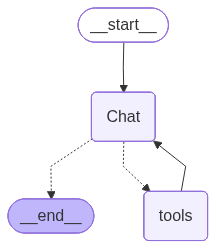

In [17]:
graph